# MIT-BIH AFDB — 5-Fold Cross-Validation (3 Hold-Out Test + 20 CV)

**Dataset:** MIT-BIH Atrial Fibrillation Database  
**Task:** Binary classification — AFib vs Non-AFib  
**Model:** KanResWideX (baseline architecture, 2 channels)  
**Setup:** 3 records held out as a fixed test set, 5-fold CV on remaining 20 records (16 train / 4 val per fold)

### Metrics reported per fold and averaged:
- Accuracy, Precision, Recall, F1, MCC
- AUROC, AUPRC
- TN, FP, FN, TP
- ECE, MCE, Brier Score
- Calibration Curves (Reliability Diagrams)


In [1]:
import sys
print(sys.executable)

/home/issar/anaconda3/envs/thesis/bin/python


## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import KFold
from collections import Counter
from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Model Definition (Baseline Architecture, 2 Channels)

In [3]:
class KanResInit(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride)
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2)
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x

class KanResModule(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride, padding='same')
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2, padding='same')
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = out + identity
        return out

class KanResWideX(nn.Module):
    def __init__(self, input_channels=2, output_size=2):
        super().__init__()
        self.init_block = KanResInit(input_channels, 64, 32, 8, 3, 1)
        self.pool = nn.AvgPool1d(kernel_size=2)
        self.res_modules = nn.ModuleList([
            KanResModule(32, 64, 32, 50, 50, 1) for _ in range(8)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, output_size)

    def forward(self, x):
        x = self.init_block(x)
        x = self.pool(x)
        for res_module in self.res_modules:
            x = res_module(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

print("Model defined.")
total_params = sum(p.numel() for p in KanResWideX().parameters())
print(f"Total parameters: {total_params:,}")

Model defined.
Total parameters: 1,648,226


## 3. Configuration

In [6]:
class Config:
    data_dir = "/home/issar/files"
    fs = 250
    num_channels = 2
    window_seconds = 4
    window_size = fs * window_seconds
    stride_seconds = 2
    stride_size = fs * stride_seconds
    skip_records = ["00735", "03665"]
    num_classes = 2
    batch_size = 64
    num_epochs = 50
    learning_rate = 1e-3
    weight_decay = 1e-4
    early_stop_patience = 10
    n_folds = 5
    n_test_records = 3
    random_seed = 42

config = Config()
assert os.path.exists(config.data_dir), f"Data path not found: {config.data_dir}"
print(f"Data path OK: {config.data_dir}")
print(f"Channels: {config.num_channels}")
print(f"Window: {config.window_size} samples ({config.window_seconds}s)")
print(f"Stride: {config.stride_size} samples ({config.stride_seconds}s)")
print(f"Hold-out test: {config.n_test_records} records")
print(f"CV folds: {config.n_folds} on remaining 20 records (16 train / 4 val per fold)")
print(f"Early stopping patience: {config.early_stop_patience}")

Data path OK: /home/issar/files
Channels: 2
Window: 1000 samples (4s)
Stride: 500 samples (2s)
Hold-out test: 3 records
CV folds: 5 on remaining 20 records (16 train / 4 val per fold)
Early stopping patience: 10


## 4. Data Loading & Windowing (2 Channels)

In [7]:
def get_record_list(data_dir):
    records = sorted(set(os.path.splitext(f)[0] for f in os.listdir(data_dir) if f.endswith(".dat")))
    print(f"Found {len(records)} records with signal files")
    return records

def load_rhythm_annotations(data_dir, record_name):
    try:
        ann = wfdb.rdann(os.path.join(data_dir, record_name), "atr")
    except Exception as e:
        print(f"  Warning: Could not read annotations for {record_name}: {e}")
        return []
    try:
        record = wfdb.rdheader(os.path.join(data_dir, record_name))
        total_samples = record.sig_len
    except Exception:
        total_samples = 10 * 3600 * config.fs
    segments = []
    for i in range(len(ann.sample)):
        start = ann.sample[i]
        end = ann.sample[i + 1] if i + 1 < len(ann.sample) else total_samples
        label = ann.aux_note[i] if ann.aux_note[i] else None
        if label:
            label = label.strip().strip("(").strip()
            if label in ("AFIB", "AF"): label = "AF"
            elif label == "AFL": label = "AFL"
            elif label == "J": label = "J"
            else: label = "N"
        if label and end > start:
            segments.append((start, end, label))
    return segments

def create_windows_for_record(data_dir, record_name, config):
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = record.p_signal
        if signal.shape[1] < config.num_channels:
            signal = np.column_stack([signal[:, 0]] * config.num_channels)
    except Exception as e:
        print(f"  Warning: Could not read signal for {record_name}: {e}")
        return None, None, None
    segments = load_rhythm_annotations(data_dir, record_name)
    if not segments:
        return None, None, None
    total_samples = len(signal)
    sample_labels = np.zeros(total_samples, dtype=np.int64)
    afib_events = 0
    for start, end, rhythm in segments:
        if rhythm == "AF":
            sample_labels[max(start, 0):min(end, total_samples)] = 1
            afib_events += 1
    windows, labels = [], []
    win_start = 0
    while win_start + config.window_size <= total_samples:
        win_end = win_start + config.window_size
        win_signal = signal[win_start:win_end, :config.num_channels].copy()
        if np.any(np.isnan(win_signal)):
            win_start += config.stride_size
            continue
        valid = True
        for ch in range(config.num_channels):
            std = np.std(win_signal[:, ch])
            if std < 1e-6:
                valid = False
                break
            win_signal[:, ch] = (win_signal[:, ch] - np.mean(win_signal[:, ch])) / std
        if not valid:
            win_start += config.stride_size
            continue
        windows.append(win_signal.T.copy())
        afib_ratio = np.mean(sample_labels[win_start:win_end])
        labels.append(1 if afib_ratio > 0.5 else 0)
        win_start += config.stride_size
    if not windows:
        return None, None, None
    windows = np.array(windows, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    stats = {"afib_events": afib_events, "total_windows": len(labels),
             "afib_windows": int(np.sum(labels == 1)), "non_afib_windows": int(np.sum(labels == 0))}
    return windows, labels, stats

print("Functions defined.")

Functions defined.


## 5. Load All Records

In [8]:
records = get_record_list(config.data_dir)
records = [r for r in records if r not in config.skip_records]
all_record_data = {}
total_stats = {"afib_events": 0, "total_windows": 0, "afib_windows": 0, "non_afib_windows": 0}

print(f"\n{'Record':<10} {'AFib Events':<15} {'Total Win':<12} {'AFib Win':<12} {'Non-AFib Win':<15}")
print("-" * 65)
for record_name in records:
    windows, labels, stats = create_windows_for_record(config.data_dir, record_name, config)
    if windows is not None:
        all_record_data[record_name] = (windows, labels)
        for key in total_stats:
            total_stats[key] += stats[key]
        print(f"{record_name:<10} {stats['afib_events']:<15} {stats['total_windows']:<12} {stats['afib_windows']:<12} {stats['non_afib_windows']:<15}")
print("-" * 65)
print(f"{'TOTAL':<10} {total_stats['afib_events']:<15} {total_stats['total_windows']:<12} {total_stats['afib_windows']:<12} {total_stats['non_afib_windows']:<15}")
print(f"\nRecords loaded: {len(all_record_data)}")

Found 23 records with signal files

Record     AFib Events     Total Win    AFib Win     Non-AFib Win   
-----------------------------------------------------------------
04015      7               18410        119          18291          
04043      82              18407        3966         14441          
04048      7               18410        180          18230          
04126      7               18410        688          17722          
04746      5               18410        9776         8634           
04908      8               18410        1541         16869          
04936      36              18410        13281        5129           
05091      8               18410        41           18369          
05121      20              18410        11604        6806           
05261      11              18410        242          18168          
06426      26              18410        17559        851            
06453      6               16649        187          16462          
0

## 6. Dataset & Helper Functions

In [9]:
class ECGDataset(Dataset):
    def __init__(self, windows, labels):
        self.windows = torch.FloatTensor(windows)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.windows[idx], self.labels[idx]

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return running_loss / total, correct / total

def evaluate_full(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    total = len(all_targets)
    return running_loss / total, np.array(all_targets), np.array(all_preds), np.array(all_probs)

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, pos_label=1, zero_division=0)
    rec = recall_score(targets, preds, pos_label=1, zero_division=0)
    f1 = f1_score(targets, preds, pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(targets, preds)
    auroc = roc_auc_score(targets, probs)
    auprc = average_precision_score(targets, probs)
    brier = brier_score_loss(targets, probs)
    n_bins = 10
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (probs >= bin_boundaries[i]) & (probs < bin_boundaries[i + 1])
        else:
            mask = (probs >= bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        bin_count = mask.sum()
        if bin_count > 0:
            bin_acc = targets[mask].mean()
            bin_conf = probs[mask].mean()
            cal_error = abs(bin_acc - bin_conf)
            ece += (bin_count / len(targets)) * cal_error
            mce = max(mce, cal_error)
    metrics = {"tn": tn, "fp": fp, "fn": fn, "tp": tp, "accuracy": acc, "precision": prec,
               "recall": rec, "f1": f1, "mcc": mcc, "auroc": auroc, "auprc": auprc,
               "brier": brier, "ece": ece, "mce": mce, "cm": cm}
    return metrics

def merge_records(record_list):
    w_list, l_list = [], []
    for r in record_list:
        w, l = all_record_data[r]
        w_list.append(w)
        l_list.append(l)
    return np.concatenate(w_list), np.concatenate(l_list)

print("All functions defined.")

All functions defined.


## 7. Split: Hold-Out Test Set + 5-Fold CV

23 records total:
- **3 records** held out as a fixed test set (never used during CV)
- **20 records** used for 5-fold CV: each fold uses 4 records for validation and 16 for training
- After CV, the best-fold model is evaluated on the held-out test set

In [10]:
np.random.seed(config.random_seed)
record_names = sorted(all_record_data.keys())
shuffled = np.random.permutation(record_names).tolist()

# Split: 3 hold-out test records + 20 CV records
test_records = shuffled[:config.n_test_records]
cv_records = shuffled[config.n_test_records:]

print(f"Hold-out test records ({len(test_records)}): {test_records}")
print(f"CV records ({len(cv_records)}): {cv_records}")

test_win = sum(len(all_record_data[r][1]) for r in test_records)
test_afib = sum(np.sum(all_record_data[r][1] == 1) for r in test_records)
cv_win = sum(len(all_record_data[r][1]) for r in cv_records)
cv_afib = sum(np.sum(all_record_data[r][1] == 1) for r in cv_records)
print(f"\nTest set: {test_win:,} windows (AFib: {test_afib:,}, Non-AFib: {test_win - test_afib:,})")
print(f"CV set:   {cv_win:,} windows (AFib: {cv_afib:,}, Non-AFib: {cv_win - cv_afib:,})")

# Create 5-fold CV splits from the 20 CV records
kf = KFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)

folds = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cv_records)):
    train_recs = [cv_records[i] for i in train_idx]
    val_recs = [cv_records[i] for i in val_idx]
    folds.append({"train": train_recs, "val": val_recs})

print(f"\n{'='*70}")
print(f"5-Fold Cross-Validation Splits (on 20 CV records):")
print(f"{'='*70}")
for i, fold in enumerate(folds):
    train_win = sum(len(all_record_data[r][1]) for r in fold["train"])
    val_win = sum(len(all_record_data[r][1]) for r in fold["val"])
    train_afib = sum(np.sum(all_record_data[r][1] == 1) for r in fold["train"])
    val_afib = sum(np.sum(all_record_data[r][1] == 1) for r in fold["val"])
    print(f"\nFold {i+1}:")
    print(f"  Train ({len(fold['train'])} records): {fold['train']}")
    print(f"    Windows: {train_win:,} (AFib: {train_afib:,})")
    print(f"  Val   ({len(fold['val'])} records):  {fold['val']}")
    print(f"    Windows: {val_win:,} (AFib: {val_afib:,})")

Hold-out test records (3): ['07879', '05261', '04015']
CV records (20): ['05121', '08215', '06995', '04043', '07162', '04908', '04048', '06453', '08405', '04126', '04746', '08219', '07910', '08434', '08455', '05091', '06426', '07859', '08378', '04936']

Test set: 55,230 windows (AFib: 11,462, Non-AFib: 43,768)
CV set:   366,424 windows (AFib: 156,647, Non-AFib: 209,777)

5-Fold Cross-Validation Splits (on 20 CV records):

Fold 1:
  Train (16 records): ['06995', '04043', '07162', '04908', '04048', '06453', '08405', '04126', '04746', '08219', '07910', '08434', '08455', '06426', '08378', '04936']
    Windows: 292,784 (AFib: 111,756)
  Val   (4 records):  ['05121', '08215', '05091', '07859']
    Windows: 73,640 (AFib: 44,891)

Fold 2:
  Train (16 records): ['05121', '08215', '06995', '07162', '04048', '06453', '04126', '04746', '07910', '08434', '08455', '05091', '06426', '07859', '08378', '04936']
    Windows: 292,790 (AFib: 133,875)
  Val   (4 records):  ['04043', '04908', '08405', '0821

## 8. Run 5-Fold Cross-Validation

In [11]:
all_fold_metrics = []
all_fold_targets = []
all_fold_preds = []
all_fold_probs = []
all_fold_histories = []
all_fold_model_states = []

total_cv_start = time.time()

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{config.n_folds} | Val records: {fold['val']}")
    print(f"{'='*70}")

    X_train, y_train = merge_records(fold["train"])
    X_val, y_val = merge_records(fold["val"])
    print(f"  Train: {len(y_train):,} (AFib: {np.sum(y_train==1):,}) | Val: {len(y_val):,} (AFib: {np.sum(y_val==1):,})")

    train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=config.batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = KanResWideX(input_channels=config.num_channels, output_size=config.num_classes).to(device)

    class_counts = Counter(y_train.tolist())
    class_weights = torch.FloatTensor([len(y_train) / (config.num_classes * class_counts[i]) for i in range(config.num_classes)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": []}

    print(f"  {'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Time':<8}")
    print(f"  {'-'*52}")

    fold_start = time.time()
    for epoch in range(1, config.num_epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, _, _, _ = evaluate_full(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        epoch_time = time.time() - epoch_start
        note = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            note = " *"
        else:
            patience_counter += 1
        print(f"  {epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {epoch_time:<.0f}s{note}")
        if patience_counter >= config.early_stop_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    fold_time = time.time() - fold_start
    model.load_state_dict(best_model_state)
    _, targets, preds, probs = evaluate_full(model, val_loader, criterion, device)
    metrics = compute_all_metrics(targets, preds, probs)

    all_fold_metrics.append(metrics)
    all_fold_targets.append(targets)
    all_fold_preds.append(preds)
    all_fold_probs.append(probs)
    all_fold_histories.append(history)
    all_fold_model_states.append(best_model_state)

    print(f"\n  Fold {fold_idx+1} ({fold_time/60:.1f} min): Acc={metrics['accuracy']:.4f} F1={metrics['f1']:.4f} MCC={metrics['mcc']:.4f} AUROC={metrics['auroc']:.4f} AUPRC={metrics['auprc']:.4f}")
    print(f"  TN={metrics['tn']} FP={metrics['fp']} FN={metrics['fn']} TP={metrics['tp']}")
    print(f"  Brier={metrics['brier']:.4f} ECE={metrics['ece']:.4f} MCE={metrics['mce']:.4f}")

total_cv_time = time.time() - total_cv_start
print(f"\n\nTotal CV time: {total_cv_time/60:.1f} minutes")


FOLD 1/5 | Val records: ['05121', '08215', '05091', '07859']
  Train: 292,784 (AFib: 111,756) | Val: 73,640 (AFib: 44,891)
  Epoch    Train Loss   Train Acc    Val Loss     Time    
  ----------------------------------------------------
  1        0.0550       0.9816       0.1958       114s *
  2        0.0312       0.9901       0.1189       113s *
  3        0.0263       0.9917       0.1714       113s
  4        0.0236       0.9924       0.1051       113s *
  5        0.0215       0.9928       0.2077       113s
  6        0.0203       0.9933       0.0656       113s *
  7        0.0196       0.9935       0.1603       113s
  8        0.0189       0.9936       0.1899       113s
  9        0.0180       0.9940       0.1705       113s
  10       0.0176       0.9940       0.1216       113s
  11       0.0136       0.9953       0.1407       113s
  12       0.0128       0.9956       0.1288       116s
  13       0.0126       0.9955       0.3682       113s
  14       0.0126       0.9955       0.

## 9. Cross-Validation Summary Table

In [12]:
metric_names = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce", "tn", "fp", "fn", "tp"]

print("=" * 120)
print("5-FOLD CROSS-VALIDATION RESULTS (Validation Folds)")
print("=" * 120)
header = f"{'Metric':<12}"
for i in range(len(folds)):
    header += f"{'Fold '+str(i+1):<14}"
header += f"{'Mean':<14}{'Std':<14}"
print(header)
print("-" * 120)

for metric in metric_names:
    values = [m[metric] for m in all_fold_metrics]
    row = f"{metric.upper():<12}"
    for v in values:
        if metric in ["tn", "fp", "fn", "tp"]:
            row += f"{int(v):<14}"
        else:
            row += f"{v:<14.4f}"
    mean_v, std_v = np.mean(values), np.std(values)
    if metric in ["tn", "fp", "fn", "tp"]:
        row += f"{mean_v:<14.0f}{std_v:<14.0f}"
    else:
        row += f"{mean_v:<14.4f}{std_v:<14.4f}"
    print(row)
print("=" * 120)

5-FOLD CROSS-VALIDATION RESULTS (Validation Folds)
Metric      Fold 1        Fold 2        Fold 3        Fold 4        Fold 5        Mean          Std           
------------------------------------------------------------------------------------------------------------------------
ACCURACY    0.9817        0.7318        0.9185        0.7854        0.9197        0.8674        0.0933        
PRECISION   0.9887        0.5381        0.8700        0.7988        0.8007        0.7993        0.1477        
RECALL      0.9812        0.9370        0.9464        0.7385        0.9953        0.9197        0.0931        
F1          0.9849        0.6836        0.9066        0.7675        0.8875        0.8460        0.1070        
MCC         0.9617        0.5348        0.8368        0.5703        0.8379        0.7483        0.1665        
AUROC       0.9950        0.7688        0.9725        0.8664        0.9958        0.9197        0.0893        
AUPRC       0.9949        0.5363        0.9510     

## 10. Hold-Out Test Set Evaluation

Select the best fold model (by validation F1) and evaluate on the 3 held-out test records.

In [13]:
# Select best fold by validation F1
val_f1s = [m["f1"] for m in all_fold_metrics]
best_fold_idx = np.argmax(val_f1s)
print(f"Best fold: Fold {best_fold_idx+1} (Val F1={val_f1s[best_fold_idx]:.4f})")
print(f"Hold-out test records: {test_records}")

best_model = KanResWideX(input_channels=config.num_channels, output_size=config.num_classes).to(device)
best_model.load_state_dict(all_fold_model_states[best_fold_idx])

X_test, y_test = merge_records(test_records)
print(f"Test set: {len(y_test):,} windows (AFib: {np.sum(y_test==1):,}, Non-AFib: {np.sum(y_test==0):,})")

test_criterion = nn.CrossEntropyLoss()
test_loader = DataLoader(ECGDataset(X_test, y_test), batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)
_, test_targets, test_preds, test_probs = evaluate_full(best_model, test_loader, test_criterion, device)
test_metrics = compute_all_metrics(test_targets, test_preds, test_probs)

print(f"\n{'='*60}")
print(f"HOLD-OUT TEST SET RESULTS (Best Fold {best_fold_idx+1})")
print(f"{'='*60}")
print(f"  Accuracy:   {test_metrics['accuracy']:.4f}")
print(f"  Precision:  {test_metrics['precision']:.4f}")
print(f"  Recall:     {test_metrics['recall']:.4f}")
print(f"  F1:         {test_metrics['f1']:.4f}")
print(f"  MCC:        {test_metrics['mcc']:.4f}")
print(f"  AUROC:      {test_metrics['auroc']:.4f}")
print(f"  AUPRC:      {test_metrics['auprc']:.4f}")
print(f"  Brier:      {test_metrics['brier']:.4f}")
print(f"  ECE:        {test_metrics['ece']:.4f}")
print(f"  MCE:        {test_metrics['mce']:.4f}")
print(f"  TN={test_metrics['tn']}  FP={test_metrics['fp']}  FN={test_metrics['fn']}  TP={test_metrics['tp']}")

Best fold: Fold 1 (Val F1=0.9849)
Hold-out test records: ['07879', '05261', '04015']
Test set: 55,230 windows (AFib: 11,462, Non-AFib: 43,768)

HOLD-OUT TEST SET RESULTS (Best Fold 1)
  Accuracy:   0.9646
  Precision:  0.8654
  Recall:     0.9825
  F1:         0.9202
  MCC:        0.9006
  AUROC:      0.9959
  AUPRC:      0.9852
  Brier:      0.0271
  ECE:        0.0474
  MCE:        0.3977
  TN=42016  FP=1752  FN=201  TP=11261


## 11. Confusion Matrices (All CV Folds + Test)

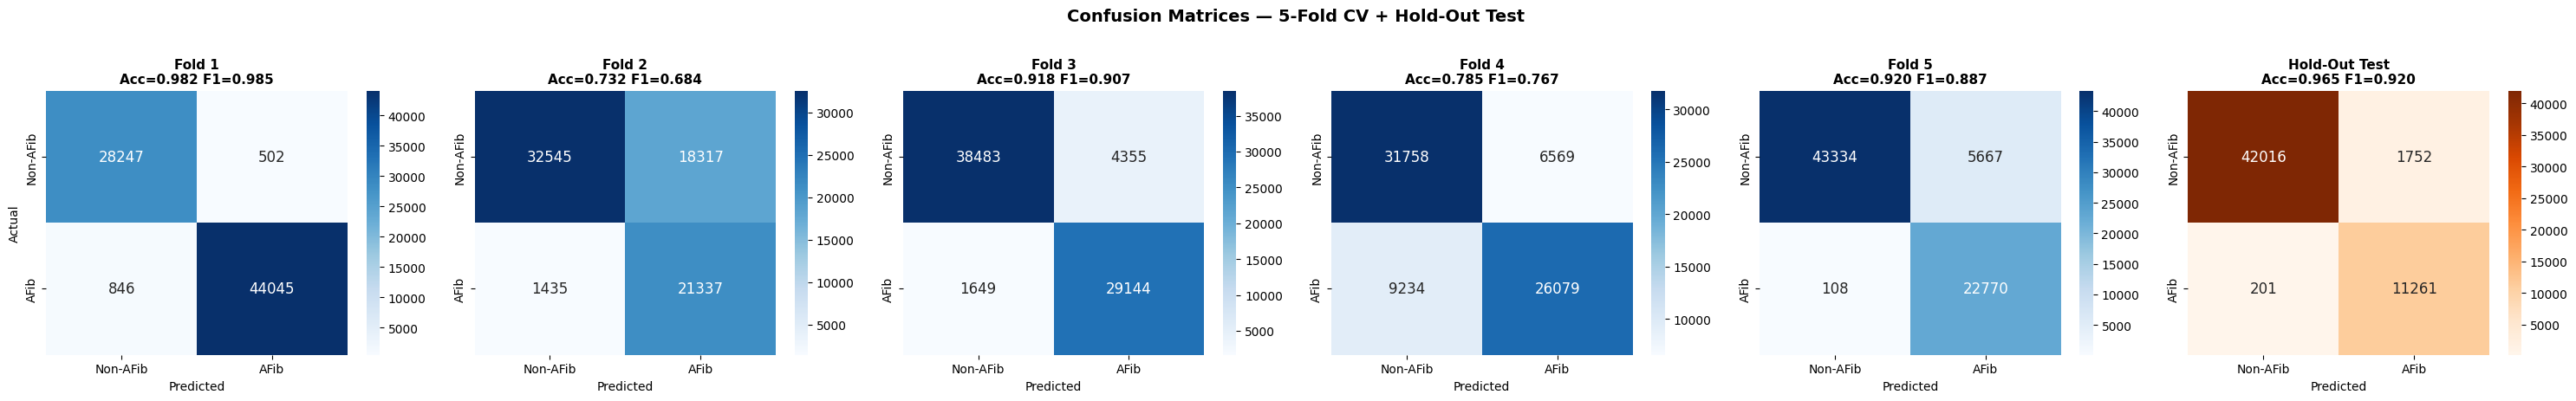

In [14]:
fig, axes = plt.subplots(1, 6, figsize=(30, 4.5))

for i, metrics in enumerate(all_fold_metrics):
    ax = axes[i]
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-AFib", "AFib"], yticklabels=["Non-AFib", "AFib"],
                ax=ax, annot_kws={"size": 12})
    ax.set_title(f"Fold {i+1}\nAcc={metrics['accuracy']:.3f} F1={metrics['f1']:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if i == 0 else "")

ax = axes[5]
sns.heatmap(test_metrics["cm"], annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Non-AFib", "AFib"], yticklabels=["Non-AFib", "AFib"],
            ax=ax, annot_kws={"size": 12})
ax.set_title(f"Hold-Out Test\nAcc={test_metrics['accuracy']:.3f} F1={test_metrics['f1']:.3f}", fontsize=11, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("")

plt.suptitle("Confusion Matrices — 5-Fold CV + Hold-Out Test", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. ROC Curves (All CV Folds + Test + Mean)

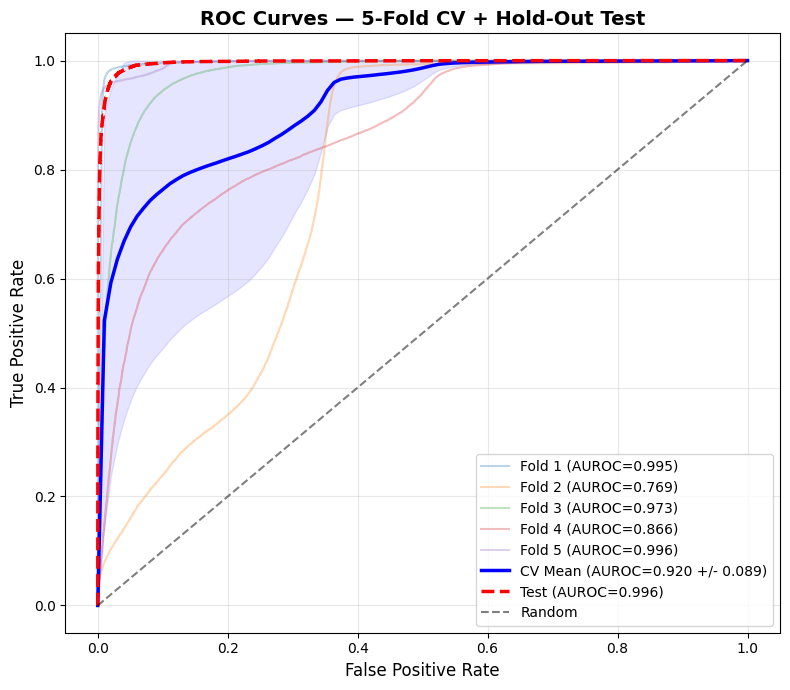

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
for i in range(len(folds)):
    fpr, tpr, _ = roc_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(fpr, tpr, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUROC={all_fold_metrics[i]["auroc"]:.3f})')
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auroc = np.mean([m["auroc"] for m in all_fold_metrics])
std_auroc = np.std([m["auroc"] for m in all_fold_metrics])
ax.plot(mean_fpr, mean_tpr, color='blue', linewidth=2.5, label=f'CV Mean (AUROC={mean_auroc:.3f} +/- {std_auroc:.3f})')
std_tpr = np.std(tprs, axis=0)
ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1), color='blue', alpha=0.1)

fpr_test, tpr_test, _ = roc_curve(test_targets, test_probs)
ax.plot(fpr_test, tpr_test, color='red', linewidth=2.5, linestyle='--', label=f'Test (AUROC={test_metrics["auroc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — 5-Fold CV + Hold-Out Test', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Precision-Recall Curves (All CV Folds + Test + Mean)

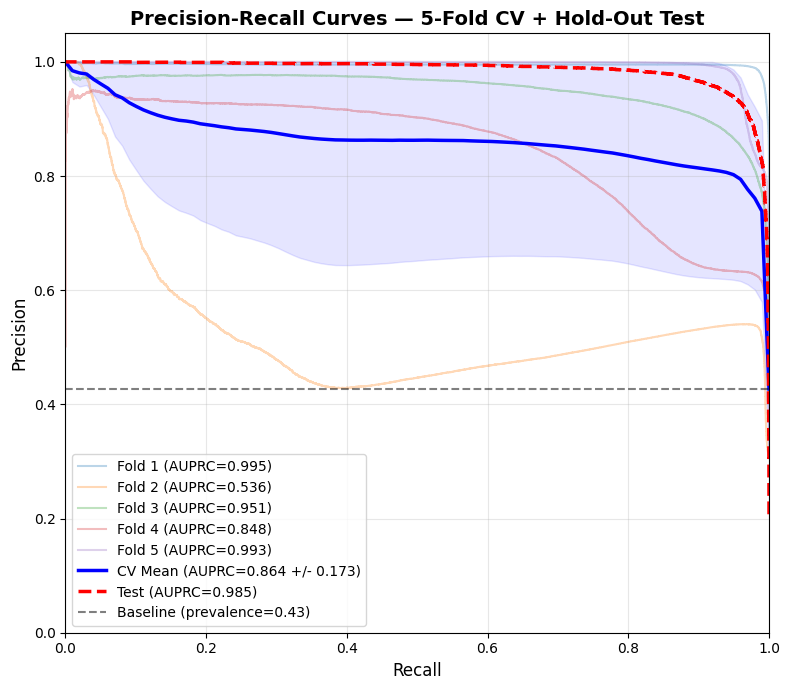

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_recall_pts = np.linspace(0, 1, 100)
precisions_interp = []
for i in range(len(folds)):
    prec_c, rec_c, _ = precision_recall_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(rec_c, prec_c, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUPRC={all_fold_metrics[i]["auprc"]:.3f})')
    prec_interp = np.interp(mean_recall_pts, rec_c[::-1], prec_c[::-1])
    precisions_interp.append(prec_interp)
mean_prec = np.mean(precisions_interp, axis=0)
mean_auprc = np.mean([m["auprc"] for m in all_fold_metrics])
std_auprc = np.std([m["auprc"] for m in all_fold_metrics])
ax.plot(mean_recall_pts, mean_prec, color='blue', linewidth=2.5, label=f'CV Mean (AUPRC={mean_auprc:.3f} +/- {std_auprc:.3f})')
std_prec = np.std(precisions_interp, axis=0)
ax.fill_between(mean_recall_pts, np.maximum(mean_prec - std_prec, 0), np.minimum(mean_prec + std_prec, 1), color='blue', alpha=0.1)

prec_test, rec_test, _ = precision_recall_curve(test_targets, test_probs)
ax.plot(rec_test, prec_test, color='red', linewidth=2.5, linestyle='--', label=f'Test (AUPRC={test_metrics["auprc"]:.3f})')

all_targets_combined = np.concatenate(all_fold_targets)
baseline = np.mean(all_targets_combined)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — 5-Fold CV + Hold-Out Test', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 14. Calibration Plots (Reliability Diagrams, ECE, MCE, Brier)

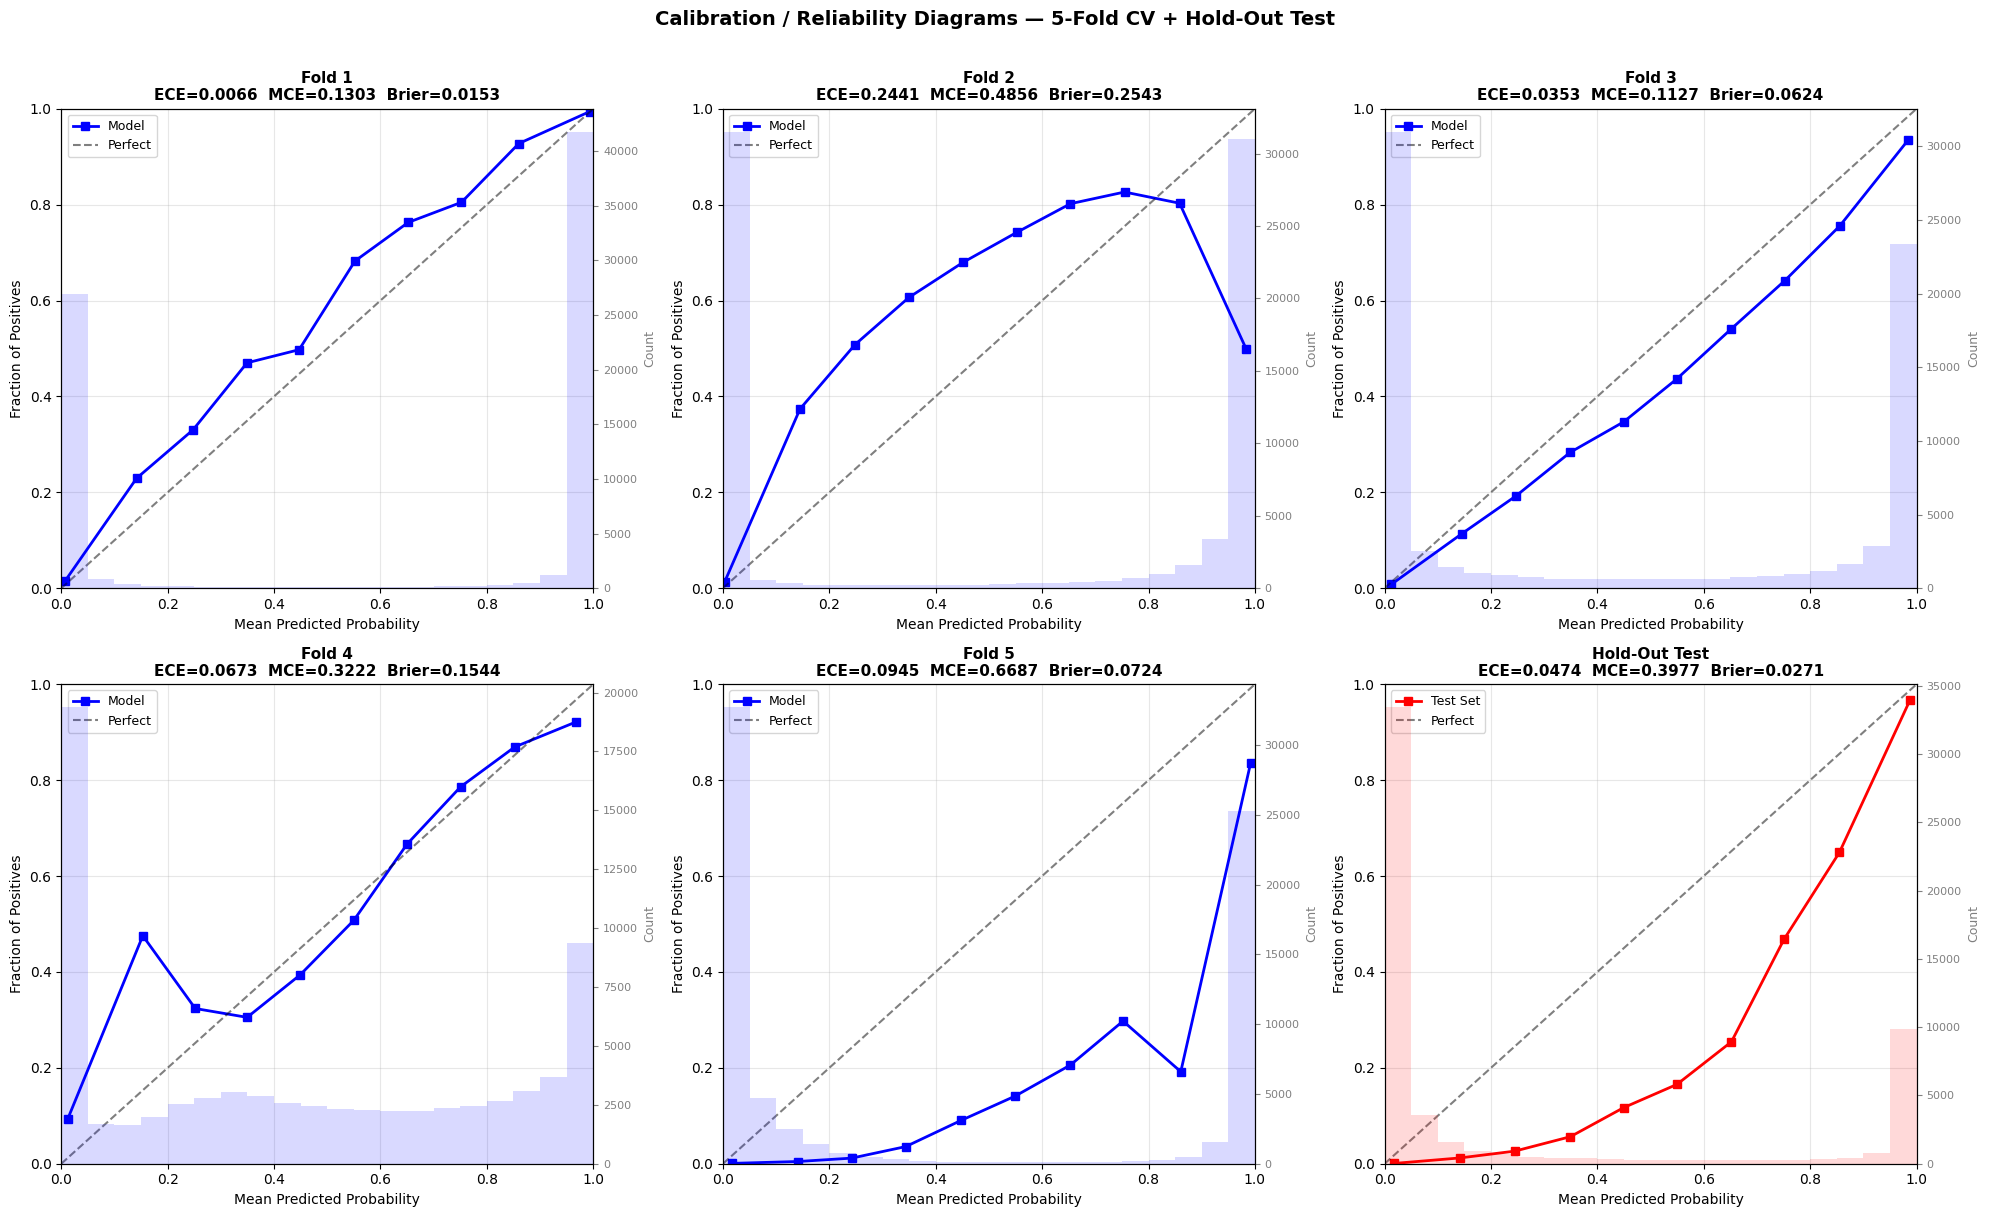

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i in range(len(folds)):
    row, col = i // 3, i % 3
    ax = axes[row][col]
    fraction_pos, mean_predicted = calibration_curve(all_fold_targets[i], all_fold_probs[i], n_bins=10, strategy='uniform')
    ax.plot(mean_predicted, fraction_pos, 's-', color='blue', linewidth=2, markersize=6, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(all_fold_probs[i], bins=20, range=(0, 1), alpha=0.15, color='blue')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    ax2.tick_params(axis='y', labelsize=8, colors='gray')
    m = all_fold_metrics[i]
    ax.set_title(f"Fold {i+1}\nECE={m['ece']:.4f}  MCE={m['mce']:.4f}  Brier={m['brier']:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

ax = axes[1][2]
fraction_pos_t, mean_predicted_t = calibration_curve(test_targets, test_probs, n_bins=10, strategy='uniform')
ax.plot(mean_predicted_t, fraction_pos_t, 's-', color='red', linewidth=2, markersize=6, label='Test Set')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax2 = ax.twinx()
ax2.hist(test_probs, bins=20, range=(0, 1), alpha=0.15, color='red')
ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
ax2.tick_params(axis='y', labelsize=8, colors='gray')
ax.set_title(f"Hold-Out Test\nECE={test_metrics['ece']:.4f}  MCE={test_metrics['mce']:.4f}  Brier={test_metrics['brier']:.4f}", fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.suptitle("Calibration / Reliability Diagrams — 5-Fold CV + Hold-Out Test", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 15. Predicted Probability Distributions

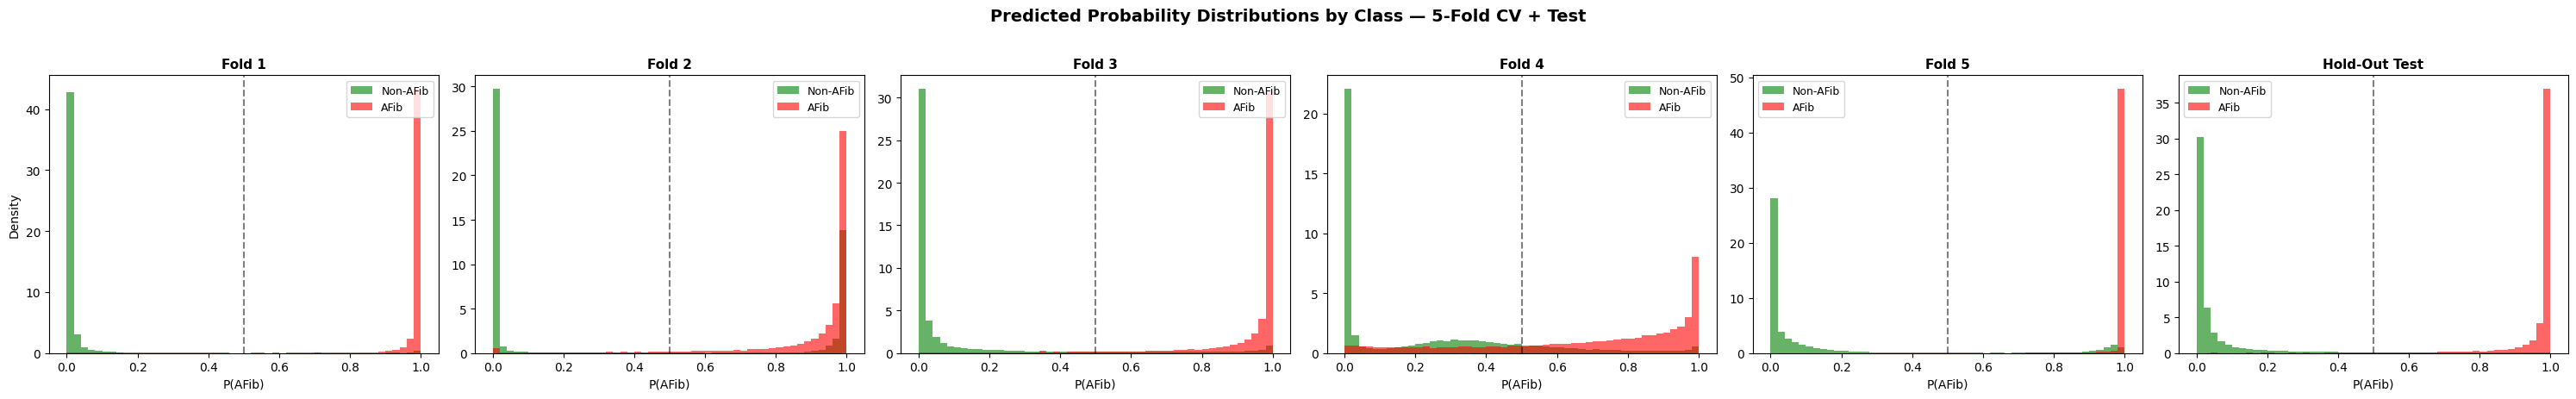

In [18]:
fig, axes = plt.subplots(1, 6, figsize=(30, 4.5))
for i in range(len(folds)):
    ax = axes[i]
    mask_neg = all_fold_targets[i] == 0
    mask_pos = all_fold_targets[i] == 1
    ax.hist(all_fold_probs[i][mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Non-AFib', density=True)
    ax.hist(all_fold_probs[i][mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Fold {i+1}", fontsize=11, fontweight='bold')
    ax.set_xlabel("P(AFib)")
    if i == 0: ax.set_ylabel("Density")
    ax.legend(fontsize=9)

ax = axes[5]
mask_neg = test_targets == 0
mask_pos = test_targets == 1
ax.hist(test_probs[mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Non-AFib', density=True)
ax.hist(test_probs[mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
ax.set_title("Hold-Out Test", fontsize=11, fontweight='bold')
ax.set_xlabel("P(AFib)")
ax.legend(fontsize=9)

plt.suptitle("Predicted Probability Distributions by Class — 5-Fold CV + Test", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 16. Metrics Comparison Across Folds

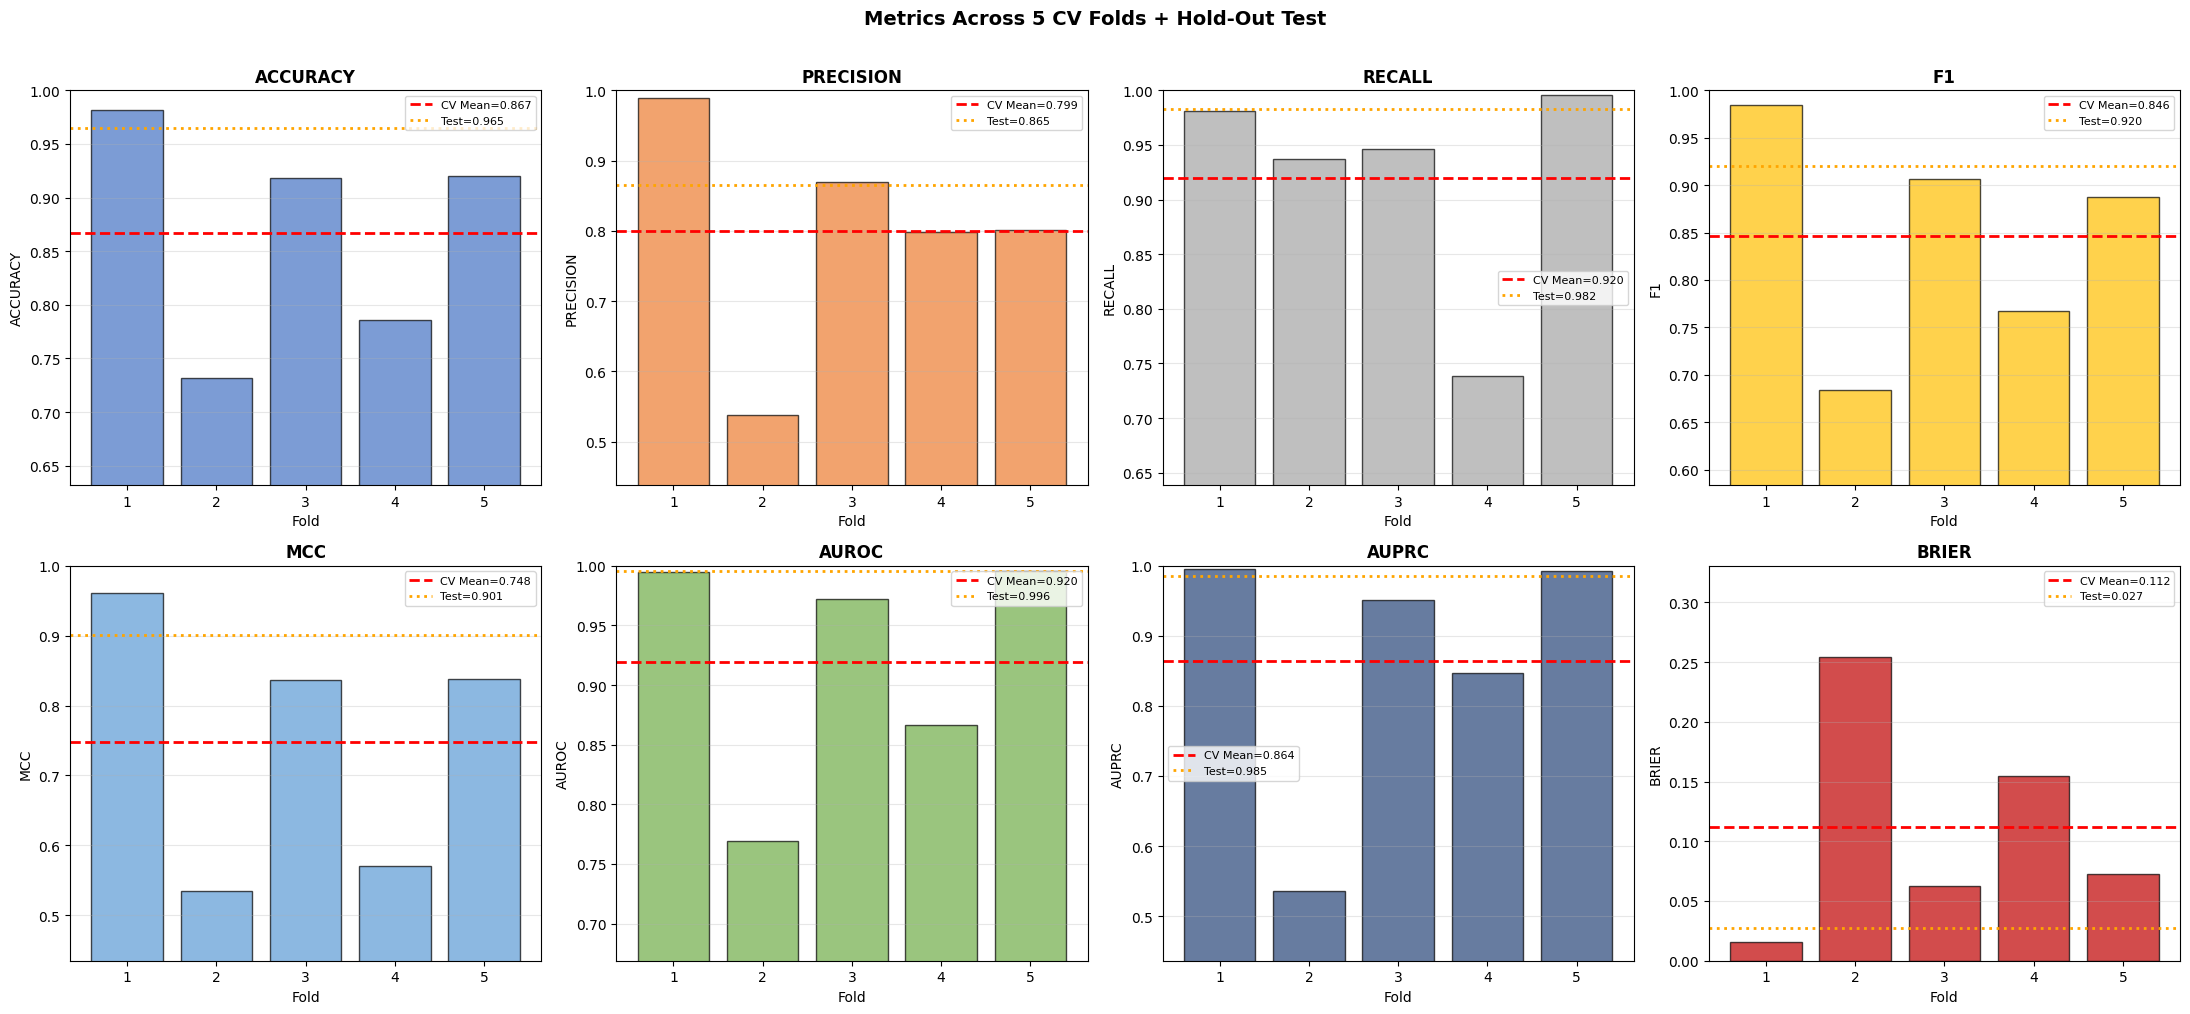

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plot_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier"]
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47', '#264478', '#C00000']
for idx, metric in enumerate(plot_metrics):
    row, col = idx // 4, idx % 4
    ax = axes[row][col]
    values = [m[metric] for m in all_fold_metrics]
    mean_val = np.mean(values)
    ax.bar(range(1, len(folds)+1), values, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'CV Mean={mean_val:.3f}')
    ax.axhline(y=test_metrics[metric], color='orange', linestyle=':', linewidth=2, label=f'Test={test_metrics[metric]:.3f}')
    ax.set_xlabel("Fold"); ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(folds)+1))
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    if metric == "brier": ax.set_ylim([0, max(max(values), test_metrics[metric]) * 1.3])
    else: ax.set_ylim([max(0, min(min(values), test_metrics[metric]) - 0.1), 1.0])
plt.suptitle("Metrics Across 5 CV Folds + Hold-Out Test", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 17. Training & Validation Loss Curves (All Folds)

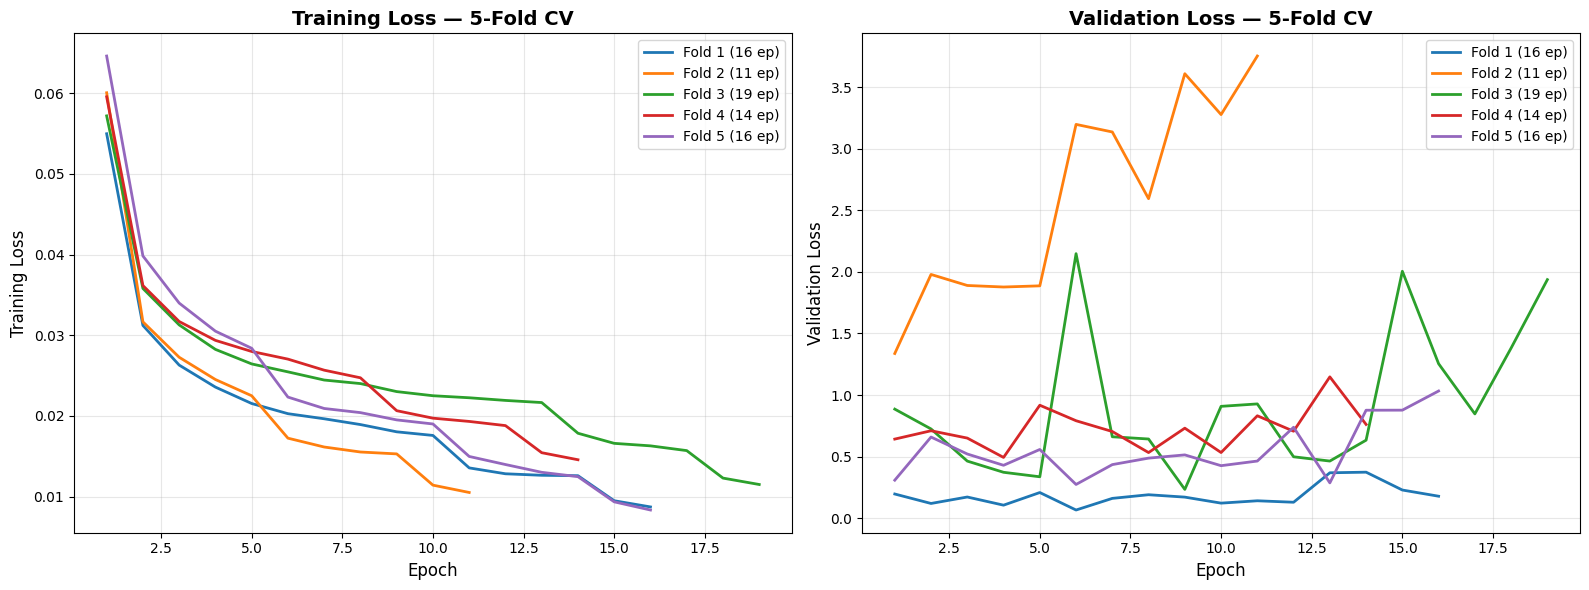

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], linewidth=2, label=f'Fold {i+1} ({len(history["train_loss"])} ep)')
ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Training Loss — 5-Fold CV", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history["val_loss"]) + 1)
    ax.plot(epochs, history["val_loss"], linewidth=2, label=f'Fold {i+1} ({len(history["val_loss"])} ep)')
ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Validation Loss — 5-Fold CV", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 18. Final Summary

In [21]:
print("=" * 70)
print("FINAL 5-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 70)
print()
summary_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]
print(f"{'Metric':<20} {'CV Mean +/- Std':<25} {'Hold-Out Test':<15}")
print("-" * 60)
for m in summary_metrics:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    test_v = test_metrics[m]
    print(f"{m.upper():<20} {mean_v:.4f} +/- {std_v:.4f}     {test_v:.4f}")
print()
print(f"{'Confusion Matrix':<20} {'CV Mean +/- Std':<25} {'Hold-Out Test':<15}")
print("-" * 60)
for m in ["tn", "fp", "fn", "tp"]:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    test_v = test_metrics[m]
    print(f"{m.upper():<20} {mean_v:.0f} +/- {std_v:.0f}          {test_v}")
print()
print(f"Model: KanResWideX (baseline architecture)")
print(f"Input: 2 channels (ECG1 + ECG2)")
print(f"Window: {config.window_size} samples ({config.window_seconds}s)")
print(f"Stride: {config.stride_size} samples ({config.stride_seconds}s)")
print(f"Hold-out test records: {test_records}")
print(f"Best CV fold: Fold {best_fold_idx+1} (Val F1={val_f1s[best_fold_idx]:.4f})")
print(f"Total CV time: {total_cv_time/60:.1f} minutes")

FINAL 5-FOLD CROSS-VALIDATION SUMMARY

Metric               CV Mean +/- Std           Hold-Out Test  
------------------------------------------------------------
ACCURACY             0.8674 +/- 0.0933     0.9646
PRECISION            0.7993 +/- 0.1477     0.8654
RECALL               0.9197 +/- 0.0931     0.9825
F1                   0.8460 +/- 0.1070     0.9202
MCC                  0.7483 +/- 0.1665     0.9006
AUROC                0.9197 +/- 0.0893     0.9959
AUPRC                0.8645 +/- 0.1726     0.9852
BRIER                0.1118 +/- 0.0842     0.0271
ECE                  0.0895 +/- 0.0827     0.0474
MCE                  0.3439 +/- 0.2122     0.3977

Confusion Matrix     CV Mean +/- Std           Hold-Out Test  
------------------------------------------------------------
TN                   34873 +/- 5360          42016
FP                   7082 +/- 5987          1752
FN                   2654 +/- 3333          201
TP                   28675 +/- 8148          11261

Model: KanRe